<a href="https://colab.research.google.com/github/RubaEgbaria/Esch-Crowd-Monitoring/blob/master/Qb2_people_counting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Qb2 LiDAR-only People Counting (DBSCAN + split + tracking) — Blickfeld recordings

Same structure as `LiDAR_pedestrian_detection.ipynb`, adapted to the Blickfeld Qb2 recordings
(`.pb` frames + background reference frame) recorded at the AE3S lab, University of Luxembourg.

Differences from the Velodyne version:
1. **Input**: `raw/frame_*.pb` (protobuf) instead of `.bin`; sensor is ceiling-mounted, looking down.
2. **Ground removal**: the recording ships a learned *background* cloud, so we do background subtraction
   (KD-tree) on top of the RANSAC floor plane -> much cleaner foreground than RANSAC alone.
3. **Coordinates**: everything is re-expressed in a *floor frame* (u, v on the floor, h = height above floor)
   so the person-size filters are the same as in the old notebook.
4. **No 3D-box labels yet**: evaluation is against a per-scenario / per-segment **manual count**
   (from the camera / screen recording), giving count MAE and exact-frame accuracy instead of P/R on boxes.
   When boxes exist later, section 8 of the old notebook plugs in unchanged.

In [1]:
!pip install blickfeld_qb2 scikit-learn scipy opencv-python-headless -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.6/136.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import numpy as np, glob, os, json, base64, zipfile, tempfile, sys
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN, KMeans
from blickfeld_qb2.core_processing.data import Frame

# ---- paths ------------------------------------------------------------------
recording_path = "/content/192.168.137.36_2026-09-08_11-33-52.zip"   # zip from the Qb2 or an unzipped folder
out_dir        = "/content/out"
os.makedirs(out_dir, exist_ok=True)

## 1) Load the recording (frames + background reference)

In [3]:
def find_recording(root):
    if root.lower().endswith(".zip"):
        tmp = tempfile.mkdtemp(prefix="qb2rec_")
        with zipfile.ZipFile(root) as z: z.extractall(tmp)
        root = tmp
    frames = sorted(glob.glob(os.path.join(root, "**", "frame_*.pb"), recursive=True))
    refs   = glob.glob(os.path.join(root, "**", "perceptPipelineReferenceFrame.json"), recursive=True)
    assert frames, "no frame_*.pb found"; assert refs, "no perceptPipelineReferenceFrame.json found"
    return frames, refs[0]

def load_frame_pb(path):
    fr = Frame().parse(open(path, "rb").read())
    xyz = np.asarray(fr.binary.cartesian, dtype=np.float32).reshape(-1, 3)
    inten = np.asarray(fr.binary.photon_count, dtype=np.float32) if len(fr.binary.photon_count) else np.zeros(len(xyz), np.float32)
    return fr.id, fr.timestamp, xyz, inten

def load_reference(path):
    r = json.load(open(path))
    return np.frombuffer(base64.b64decode(r["binary"]["cartesian"]), dtype=np.float32).reshape(-1, 3)

frame_files, ref_path = find_recording(recording_path)
background = load_reference(ref_path)
print(f"{len(frame_files)} frames, background cloud {len(background)} pts")

284 frames, background cloud 7680 pts


## 2) Floor plane + floor frame
RANSAC on the *background* cloud (same routine as `remove_ground_ransac`, but we keep the plane instead of
throwing points away). The normal matches the sensor's accelerometer, so this is the real floor.

In [4]:
def fit_floor_plane(pts, iters=3000, thresh=0.05, seed=42):
    rng = np.random.default_rng(seed); best = (0, None, None)
    for _ in range(iters):
        p = pts[rng.choice(len(pts), 3, replace=False)]
        n = np.cross(p[1]-p[0], p[2]-p[0]); nl = np.linalg.norm(n)
        if nl < 1e-6: continue
        n /= nl; d = -n @ p[0]
        cnt = int((np.abs(pts @ n + d) < thresh).sum())
        if cnt > best[0]: best = (cnt, n, d)
    _, n, d = best
    inl = pts[np.abs(pts @ n + d) < thresh]; c = inl.mean(0)
    n = np.linalg.svd(inl - c)[2][2]; d = -n @ c
    if d < 0: n, d = -n, -d                      # sensor (origin) is above the floor
    a = np.array([1., 0, 0]) if abs(n[0]) < 0.9 else np.array([0, 1., 0])
    u = np.cross(n, a); u /= np.linalg.norm(u); v = np.cross(n, u)
    return n, d, u, v, best[0] / len(pts)

n_up, d_floor, u_ax, v_ax, floor_frac = fit_floor_plane(background)
print(f"floor plane covers {floor_frac:.0%} of background, sensor height = {d_floor:.2f} m")

def to_floor_frame(xyz):
    # returns (u, v, h): u,v on the floor, h = height above floor (m)
    return np.column_stack([xyz @ u_ax, xyz @ v_ax, xyz @ n_up + d_floor])

background_f = to_floor_frame(background)
bg_tree = cKDTree(background)

floor plane covers 73% of background, sensor height = 2.31 m


In [5]:
from scipy.spatial.transform import Rotation as R

# ---- zone from the sensor config (same one the Qb2 evaluated live) --------
rec_root = os.path.dirname(os.path.dirname(ref_path))
zones = json.load(open(glob.glob(os.path.join(rec_root, "**", "perceptPipelineZones.json"), recursive=True)[0]))
ds    = json.load(open(glob.glob(os.path.join(rec_root, "**", "perceptPipelineDataSource.json"), recursive=True)[0]))
mfl   = ds["qb2Setup"]["lidars"][0]["mapFromLidar"]
q, t  = mfl["rotation"], mfl["translation"]
map_from_lidar_R = R.from_quat([q.get("x", 0), q.get("y", 0), q.get("z", 0), q.get("w", 1)])
map_from_lidar_t = np.array([t.get("x", 0), t.get("y", 0), t.get("z", 0)])

zone = zones[0]                                   # "Occupancy Zone 1"
zc  = zone["shape"]["pose"]["position"]; zd = zone["shape"]["box"]["dimensions"]
zo  = zone["shape"]["pose"].get("orientation", {})
zone_R = R.from_quat([zo.get("x", 0), zo.get("y", 0), zo.get("z", 0), zo.get("w", 1)])
print(f"zone '{zone['name']}': center ({zc['x']:.2f}, {zc['y']:.2f}) size {zd['x']}x{zd['y']} m  (z ignored)")

def in_zone_xy(xyz):
    m = map_from_lidar_R.apply(xyz) + map_from_lidar_t          # lidar -> map frame
    local = zone_R.inv().apply(m - [zc["x"], zc["y"], zc.get("z", 0)])   # into the zone's own axes
    return (np.abs(local[:, 0]) <= zd["x"] / 2) & (np.abs(local[:, 1]) <= zd["y"] / 2)

zone 'Occupancy Zone 1': center (0.50, -0.85) size 2.0x2.0 m  (z ignored)


## 3) Foreground extraction (background subtraction + floor gate)
Replaces `filter_points` + `remove_ground_ransac`: a point is foreground if **no background point lies within
`bg_dist`** and it is at least `min_h` above the floor.

In [6]:
def filter_points(xyz, bg_dist=0.15, min_h=0.10):
    f = to_floor_frame(xyz)
    dist, _ = bg_tree.query(xyz, k=1, distance_upper_bound=bg_dist)
    fg = (~np.isfinite(dist)) & (f[:, 2] > min_h) & in_zone_xy(xyz)   # <- zone filter, x/y only
    return f[fg]

## 4) DBSCAN + oversized-cluster split (from the old notebook, adapted)
Same `split_oversized_cluster` idea (KMeans by footprint / person span) — this is what fixes the
“1 person vs 6 people” flicker on touching groups. Size filters are on **height above floor** now,
and the distance-adaptive `required_points` uses distance from the sensor's floor projection.

In [7]:
def split_oversized_cluster(pts, single_person_span=0.65, max_split=4):
    w = np.ptp(pts[:, 0]); d = np.ptp(pts[:, 1])
    n_split = int(round(max(w, d) / single_person_span))
    if n_split <= 1: return [pts]
    if n_split > max_split: return []            # wall / rail / clutter
    if len(pts) < n_split * 4: return [pts]
    km = KMeans(n_clusters=n_split, n_init=5, random_state=0).fit(pts[:, :2])
    return [pts[km.labels_ == k] for k in range(n_split)]

def cluster_pedestrians(P, eps=0.10, min_samples=5, # tried eps = 10, 15, 20, 30
                        w_range=(0.15, 1.05), d_range=(0.15, 1.05), top_range=(0.9, 2.3),
                        min_height_ratio=0.5):
    if len(P) < min_samples: return []
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
    out = []
    for lbl in set(labels):
        if lbl == -1: continue
        for c in split_oversized_cluster(P[labels == lbl]):
            if len(c) < min_samples: continue
            dist = np.linalg.norm(c[:, :2].mean(0))            # from sensor footprint
            required = 25 if dist < 3 else 15 if dist < 5 else 8
            if len(c) < required: continue
            w, d = np.ptp(c[:, 0]), np.ptp(c[:, 1]); top = c[:, 2].max(); h = top - c[:, 2].min()
            if max(w, d) == 0 or h / max(w, d) < min_height_ratio: continue
            if w_range[0] < w < w_range[1] and d_range[0] < d < d_range[1] and top_range[0] < top < top_range[1]:
                out.append({"centroid": c[:, :2].mean(0), "top": float(top), "w": float(w), "d": float(d), "n": len(c)})
    return out

## 5) Temporal tracking (new)
Frames come at 7.8 Hz; a person cannot appear/vanish for one frame. Simple nearest-neighbour ID tracker
with a short grace period, then the per-frame count is the number of *confirmed* tracks. Also a rolling-median
count for the plots.

In [8]:
class SimpleTracker:
    def __init__(self, max_dist=0.6, min_hits=3, max_miss=4):
        self.tracks = {}; self.next_id = 0
        self.max_dist, self.min_hits, self.max_miss = max_dist, min_hits, max_miss
    def update(self, dets):
        cents = [d["centroid"] for d in dets]; used = set()
        for tid, t in list(self.tracks.items()):
            best, bj = self.max_dist, None
            for j, c in enumerate(cents):
                if j in used: continue
                dd = np.linalg.norm(c - t["pos"])
                if dd < best: best, bj = dd, j
            if bj is None: t["miss"] += 1
            else: t["pos"] = cents[bj]; t["hits"] += 1; t["miss"] = 0; used.add(bj)
            if t["miss"] > self.max_miss: del self.tracks[tid]
        for j, c in enumerate(cents):
            if j not in used:
                self.tracks[self.next_id] = {"pos": c, "hits": 1, "miss": 0}; self.next_id += 1
        return [(tid, t["pos"]) for tid, t in self.tracks.items() if t["hits"] >= self.min_hits and t["miss"] == 0]

## 6) Run on all frames

In [9]:
import pandas as pd
tracker = SimpleTracker()
rows, dets_per_frame = [], {}
for i, path in enumerate(frame_files):
    fid, ts, xyz, _ = load_frame_pb(path)
    P = filter_points(xyz)
    dets = cluster_pedestrians(P)
    tracked = tracker.update(dets)
    dets_per_frame[fid] = dets
    rows.append({"frame_id": fid, "timestamp_ns": ts, "t_s": ts / 1e9,
                 "n_raw": len(dets), "n_tracked": len(tracked), "n_fg_pts": len(P)})
    if i % 50 == 0: print(f"  {i}/{len(frame_files)}  raw={len(dets)} tracked={len(tracked)}")

df = pd.DataFrame(rows)
df["t_s"] -= df["t_s"].iloc[0]
df["n_smooth"] = df["n_tracked"].rolling(8, center=True, min_periods=1).median().astype(int)
df.to_csv(f"{out_dir}/counts.csv", index=False)
print(df[["n_raw", "n_tracked", "n_smooth"]].describe().loc[["mean", "50%", "max"]])

  0/284  raw=5 tracked=0
  50/284  raw=6 tracked=6
  100/284  raw=6 tracked=6
  150/284  raw=6 tracked=6
  200/284  raw=6 tracked=4
  250/284  raw=6 tracked=6
         n_raw  n_tracked  n_smooth
mean  5.584507   5.433099  5.457746
50%   6.000000   6.000000  6.000000
max   8.000000   7.000000  6.000000


## 7) Ground truth = manual counts per time segment (no boxes yet)
Fill this from the camera / screen recording: `(start_s, end_s, n_people)` relative to recording start.
Until boxes exist, this gives count MAE and exact-frame accuracy, which is what the fusion paper needs anyway.

In [10]:
# EDIT ME — seconds from the start of this recording, people in the field of view
T = df.t_s.iloc[-1]
gt_segments = [(0, 1.0, 5), (1.0, T - 2.0, 6), (T - 2.0, T + 0.2, 5)]

gt = np.full(len(df), -1)
for s, e, k in gt_segments: gt[(df.t_s >= s) & (df.t_s < e)] = k
df["gt"] = gt; m = gt >= 0

def report(pred, name):
    err = pred[m] - gt[m]
    return {"method": name,
            "MAE": np.abs(err).mean(),
            "exact %": 100 * np.mean(err == 0),
            "within ±1 %": 100 * np.mean(np.abs(err) <= 1),
            "bias": err.mean(),
            "under-count %": 100 * np.mean(err < 0),
            "over-count %": 100 * np.mean(err > 0)}

rows = [report(df.n_raw.values, "DBSCAN raw"),
        report(df.n_tracked.values, "+ tracking"),
        report(df.n_smooth.values, "+ tracking + 1 s median")]
print(pd.DataFrame(rows).round(2).to_string(index=False))

# per-segment: mean predicted count vs true
for s, e, k in gt_segments:
    seg = df[(df.t_s >= s) & (df.t_s < e)]
    print(f"{s:5.1f}–{e:5.1f}s  GT={k}  mean pred={seg.n_smooth.mean():.2f}  exact={100*np.mean(seg.n_smooth==k):.0f}%")

                 method  MAE  exact %  within ±1 %  bias  under-count %  over-count %
             DBSCAN raw 0.46    61.27        92.96 -0.33          32.75          5.99
             + tracking 0.51    59.86        91.20 -0.48          38.73          1.41
+ tracking + 1 s median 0.46    62.32        92.25 -0.46          37.68          0.00
  0.0–  1.0s  GT=5  mean pred=4.62  exact=88%
  1.0– 34.3s  GT=6  mean pred=5.57  exact=65%
 34.3– 36.5s  GT=5  mean pred=4.00  exact=0%


In [11]:
import time, psutil, os
proc = psutil.Process(os.getpid())

def count_prf(pred, gt):
    tp = np.minimum(pred, gt).sum(); fp = np.maximum(pred - gt, 0).sum(); fn = np.maximum(gt - pred, 0).sum()
    P = tp / (tp + fp) if tp + fp else 0; R = tp / (tp + fn) if tp + fn else 0
    F = 2 * P * R / (P + R) if P + R else 0
    acc = tp / (tp + fp + fn) if tp + fp + fn else 0
    return dict(TP=int(tp), FP=int(fp), FN=int(fn), Precision=P, Recall=R, F1=F, Accuracy=acc)

# ---- latency + RAM: full LiDAR pipeline per frame (load excluded, as in the old notebook) ----
def timed_run(eps):
    tr = SimpleTracker(); preds, lat, ram = [], [], []
    for path in frame_files:
        _, _, xyz, _ = load_frame_pb(path)
        t0 = time.perf_counter()
        n = len(tr.update(cluster_pedestrians(filter_points(xyz), eps=eps)))
        lat.append(time.perf_counter() - t0); ram.append(proc.memory_info().rss / 1e6)
        preds.append(n)
    preds = pd.Series(preds).rolling(8, center=True, min_periods=1).median().values.astype(int)
    return preds, np.array(lat), np.array(ram)

m = df["gt"].values >= 0; gt_m = df["gt"].values[m]
rows = []
for eps in [0.10, 0.15, 0.20, 0.30]:
    preds, lat, ram = timed_run(eps)
    r = count_prf(preds[m], gt_m)
    rows.append({"Method": f"LiDAR only (DBSCAN+KMeans, eps={eps})",
                 "Precision": f"{100*r['Precision']:.2f}%", "Recall": f"{100*r['Recall']:.2f}%",
                 "F1 Score": f"{100*r['F1']:.2f}%", "Accuracy": f"{100*r['Accuracy']:.2f}%",
                 "MAE": f"{np.abs(preds[m]-gt_m).mean():.2f}",
                 "Mean Latency ms/frame": f"{1000*lat.mean():.1f}",
                 "GFLOPs/frame": "N/A (non-NN)", "RAM MB": f"{ram.max():.1f}",
                 "_cm": (r["TP"], r["FN"], r["FP"])})
table = pd.DataFrame(rows)
print(table.drop(columns="_cm").to_string(index=False))
table.drop(columns="_cm").to_csv(f"{out_dir}/metrics_table.csv", index=False)

# ---- final row, same columns as the paper table ----
best = table.loc[table["Method"].str.contains("eps=0.1)", regex=False)].iloc[0]
paper_row = pd.DataFrame([{
    "Method": "LiDAR Only (DBSCAN)",
    "Precision": best["Precision"], "Recall": best["Recall"], "F1 Score": best["F1 Score"],
    "Mean Latency ms/frame": best["Mean Latency ms/frame"],
    "GFLOPs/frame": "N/A (non-NN)",
    "RAM in MB/frame": best["RAM MB"],
}])
print(paper_row.to_string(index=False))
paper_row.to_csv(f"{out_dir}/paper_table_lidar_row.csv", index=False)

                              Method Precision Recall F1 Score Accuracy  MAE Mean Latency ms/frame GFLOPs/frame RAM MB
 LiDAR only (DBSCAN+KMeans, eps=0.1)   100.00% 92.26%   95.98%   92.26% 0.46                  27.1 N/A (non-NN)  290.8
LiDAR only (DBSCAN+KMeans, eps=0.15)   100.00% 89.40%   94.41%   89.40% 0.63                  24.1 N/A (non-NN)  290.9
 LiDAR only (DBSCAN+KMeans, eps=0.2)   100.00% 85.83%   92.38%   85.83% 0.84                  22.6 N/A (non-NN)  291.0
 LiDAR only (DBSCAN+KMeans, eps=0.3)   100.00% 80.00%   88.89%   80.00% 1.18                  33.7 N/A (non-NN)  291.8
             Method Precision Recall F1 Score Mean Latency ms/frame GFLOPs/frame RAM in MB/frame
LiDAR Only (DBSCAN)   100.00% 92.26%   95.98%                  27.1 N/A (non-NN)           290.8


## 8) Count over time

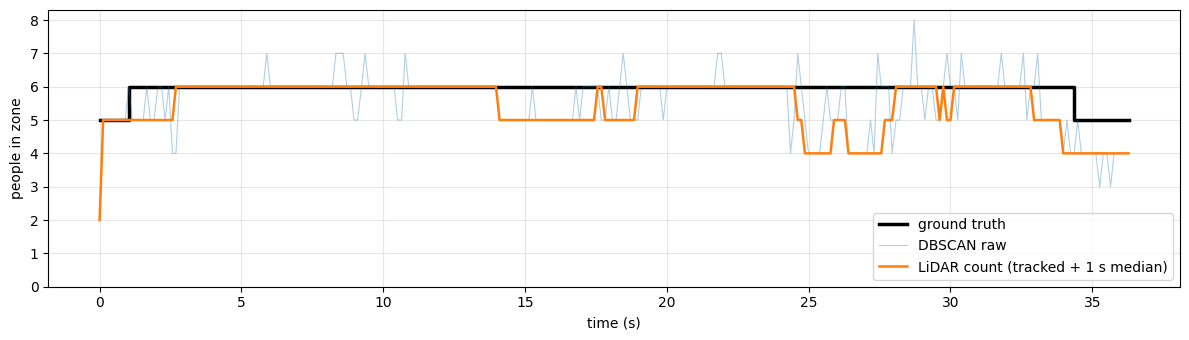

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.step(df.t_s, df["gt"].where(df["gt"] >= 0), where="post", c="k", lw=2.5, label="ground truth")
ax.plot(df.t_s, df.n_raw, lw=0.8, alpha=0.35, label="DBSCAN raw")
ax.plot(df.t_s, df.n_smooth, lw=1.8, label="LiDAR count (tracked + 1 s median)")
ax.set_yticks(range(0, 9)); ax.set_xlabel("time (s)"); ax.set_ylabel("people in zone")
ax.grid(alpha=.3); ax.legend(loc="lower right"); plt.tight_layout()
plt.savefig(f"{out_dir}/count_vs_gt.png", dpi=200); plt.show()

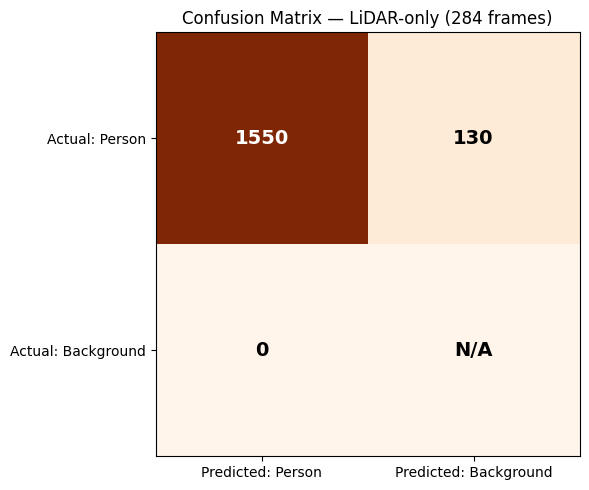

In [14]:
tp, fn, fp = table.loc[table["F1 Score"].str.rstrip('%').astype(float).idxmax(), "_cm"]
cm = np.array([[tp, fn], [fp, 0]])
fig, ax = plt.subplots(figsize=(6, 5)); ax.imshow(cm, cmap="Oranges")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted: Person", "Predicted: Background"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual: Person", "Actual: Background"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, "N/A" if (i, j) == (1, 1) else str(cm[i, j]), ha="center", va="center", fontsize=14, weight="bold",
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_title(f"Confusion Matrix — LiDAR-only ({m.sum()} frames)"); plt.tight_layout()
plt.savefig(f"{out_dir}/confusion_matrix.png", dpi=200); plt.show()

## 9) Bird's-eye view of one frame

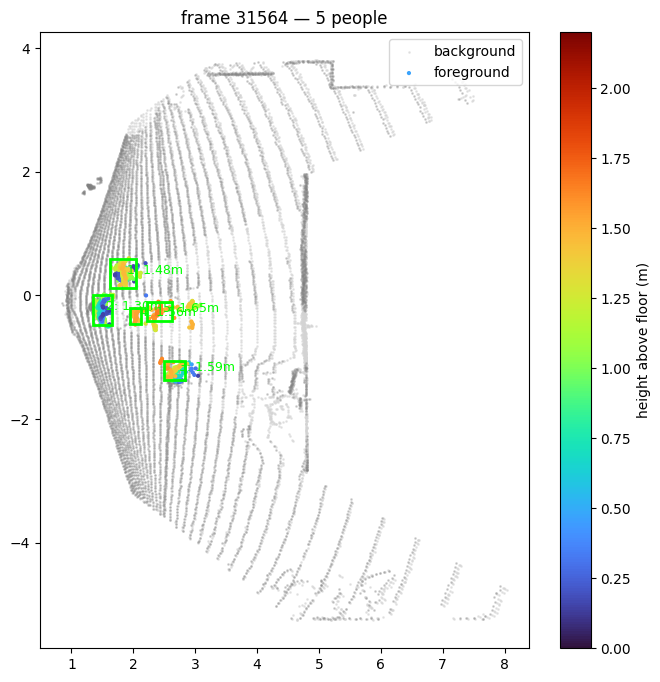

In [15]:
def visualize_frame_bev(idx):
    fid, ts, xyz, _ = load_frame_pb(frame_files[idx])
    f = to_floor_frame(xyz); P = filter_points(xyz); dets = dets_per_frame[fid]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(background_f[:, 0], background_f[:, 1], s=1, c="lightgray", alpha=.5, label="background")
    ax.scatter(f[:, 0], f[:, 1], s=1, c="gray", alpha=.3)
    sc = ax.scatter(P[:, 0], P[:, 1], s=4, c=P[:, 2], cmap="turbo", vmin=0, vmax=2.2, label="foreground")
    for k, d in enumerate(dets):
        ax.add_patch(plt.Rectangle(d["centroid"] - [d["w"]/2, d["d"]/2], d["w"], d["d"], fill=False, ec="lime", lw=2))
        ax.text(*d["centroid"], f" {k+1}: {d['top']:.2f}m", color="lime", fontsize=9)
    plt.colorbar(sc, label="height above floor (m)")
    ax.set_aspect("equal"); ax.set_title(f"frame {fid} — {len(dets)} people"); ax.legend(loc="upper right")
    plt.show()

visualize_frame_bev(len(frame_files) // 2)

## 10) Export a BEV video

In [ ]:
import cv2
def render_bev_array(idx):
    fig = plt.figure(figsize=(8, 8))
    fid, ts, xyz, _ = load_frame_pb(frame_files[idx])
    f = to_floor_frame(xyz); P = filter_points(xyz); dets = dets_per_frame[fid]
    ax = fig.add_subplot(111)
    ax.scatter(background_f[:, 0], background_f[:, 1], s=1, c="lightgray", alpha=.5)
    ax.scatter(P[:, 0], P[:, 1], s=4, c=P[:, 2], cmap="turbo", vmin=0, vmax=2.2)
    for k, d in enumerate(dets):
        ax.add_patch(plt.Rectangle(d["centroid"] - [d["w"]/2, d["d"]/2], d["w"], d["d"], fill=False, ec="lime", lw=2))
    ax.set_xlim(background_f[:, 0].min() - .5, background_f[:, 0].max() + .5)
    ax.set_ylim(background_f[:, 1].min() - .5, background_f[:, 1].max() + .5)
    ax.set_aspect("equal"); ax.set_title(f"frame {fid}  t={df.t_s.iloc[idx]:.1f}s  people={df.n_smooth.iloc[idx]}")
    fig.canvas.draw(); img = np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy(); plt.close(fig)
    return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

first = render_bev_array(0); h, w = first.shape[:2]
vw = cv2.VideoWriter(f"{out_dir}/bev.mp4", cv2.VideoWriter_fourcc(*"mp4v"), 7.8, (w, h))
for i in range(len(frame_files)):
    vw.write(render_bev_array(i))
vw.release(); print("wrote", f"{out_dir}/bev.mp4")